In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [ ]:
car_dataset = pd.read_csv('Car details v3.csv')

In [ ]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
car_dataset.shape

(8128, 13)

In [ ]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
car_dataset.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [ ]:
car_dataset.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [ ]:
print('\n Fuel Type:')
print(car_dataset['fuel'].value_counts())
print('\n Seller Type:')
print(car_dataset['seller_type'].value_counts())
print('\n Transmission:')
print(car_dataset['transmission'].value_counts())
print('\n Owner:')
print(car_dataset['owner'].value_counts())


 Fuel Type:
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

 Seller Type:
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

 Transmission:
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

 Owner:
owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Selling Price')

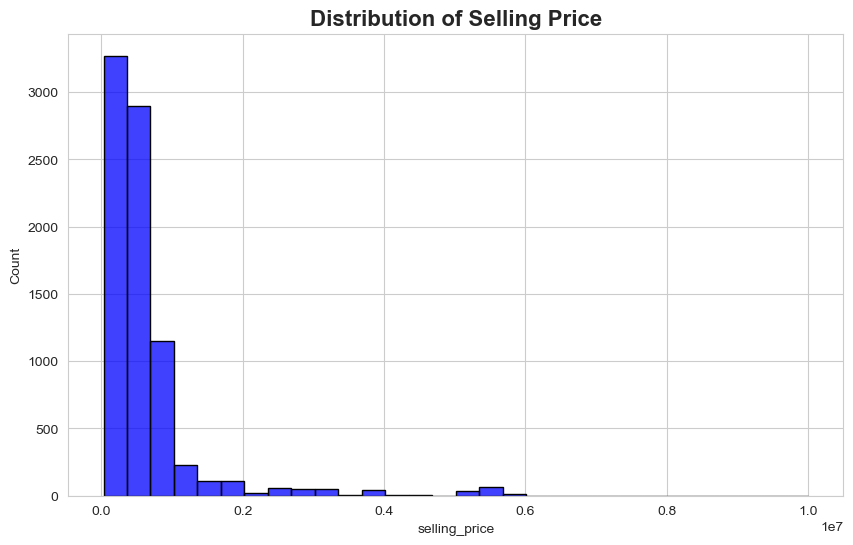

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(car_dataset['selling_price'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Selling Price', fontsize=16, fontweight='bold')

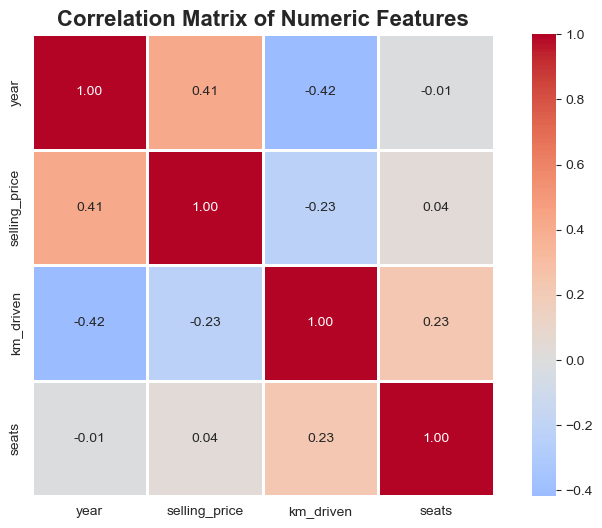

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
numeric_features = car_dataset.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold')
plt.show()

Text(0, 0.5, 'Selling Price')

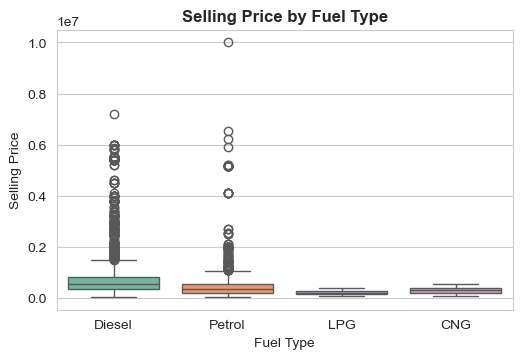

In [ ]:
plt.figure(figsize=(20, 8))
plt.subplot(2,3,1)
sns.boxplot(x=car_dataset['fuel'], y=car_dataset['selling_price'], palette='Set2')
plt.title('Selling Price by Fuel Type', fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

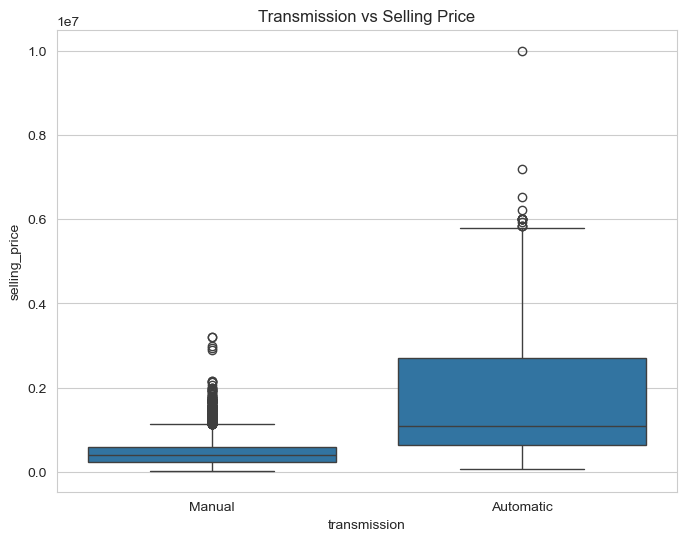

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

car_dataset.columns = car_dataset.columns.str.strip()

plt.figure(figsize=(8,6))

sns.boxplot(
    x='transmission',       
    y='selling_price',     
    data=car_dataset
)

plt.title("Transmission vs Selling Price")
plt.show()

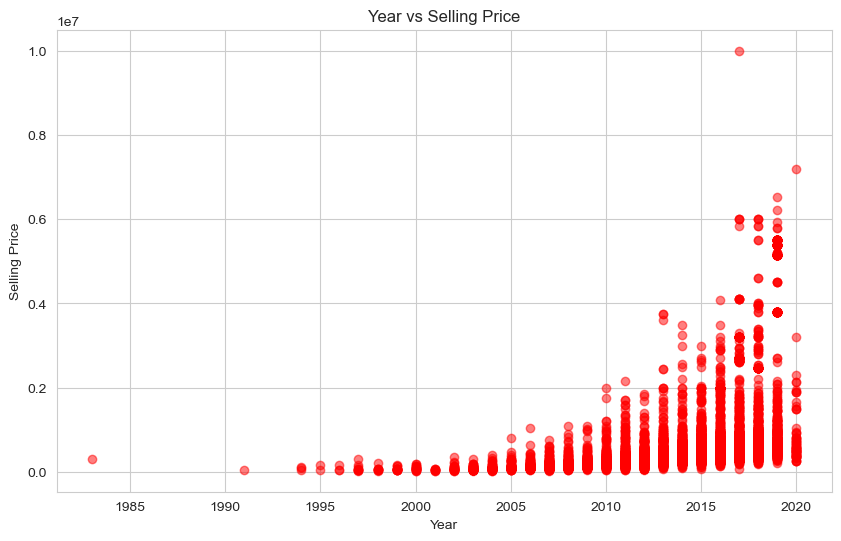

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(car_dataset['year'], car_dataset['selling_price'],alpha=0.5,color ='red')
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

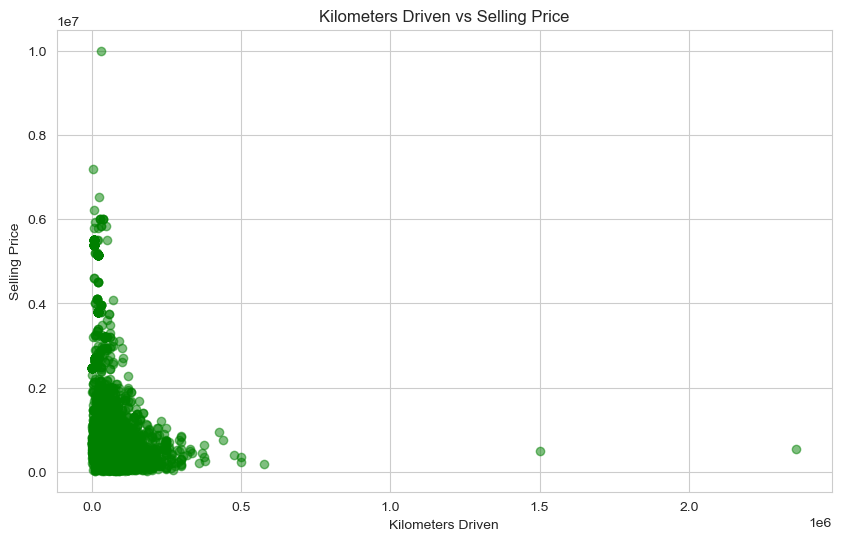

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(car_dataset['km_driven'], car_dataset['selling_price'], alpha=0.5, color='green')
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encode={}

In [ ]:
cat_cols = ['fuel','seller_type','transmission','owner']
for col in cat_cols:
    le = LabelEncoder()
    car_dataset[col]=le.fit_transform(car_dataset[col])
    label_encode[col] = le
    joblib.dump(le,f"label_encode_{col}.pkl")

In [ ]:
x = car_dataset.drop(columns=['selling_price'], errors='ignore')
y = car_dataset['selling_price']
print(x.head())

   year  km_driven  fuel  seller_type  transmission  owner  mileage  engine  \
0  2014     145500     1            1             1      0    23.40  1248.0   
1  2014     120000     1            1             1      2    21.14  1498.0   
2  2006     140000     3            1             1      4    17.70  1497.0   
3  2010     127000     1            1             1      0    23.00  1396.0   
4  2007     120000     3            1             1      0    16.10  1298.0   

   max_power  seats  
0      74.00    5.0  
1     103.52    5.0  
2      78.00    5.0  
3      90.00    5.0  
4      88.20    5.0  


In [ ]:
print(y.head())

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64


In [ ]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Training set size: {x_train.shape[0]} (80%)')


Training set size: 6502 (80%)


In [ ]:
print(f'Testing set size: {x_test.shape[0]} (20%)')

Testing set size: 1626 (20%)


In [ ]:
print(x_train.isnull().sum())

year              0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage         170
engine          170
max_power       166
torque          171
seats           170
dtype: int64


In [ ]:
x = pd.get_dummies(x, drop_first=True)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
print(x_train.dtypes)


year                       int64
km_driven                  int64
fuel                       int64
seller_type                int64
transmission               int64
                           ...  
torque_99.04Nm@ 4500rpm     bool
torque_99.07Nm@ 4500rpm     bool
torque_99.1Nm@ 4500rpm      bool
torque_99.8Nm@ 2700rpm      bool
torque_99Nm@ 4500rpm        bool
Length: 1280, dtype: object


In [ ]:
car_dataset = car_dataset.drop(['name', 'torque'], axis=1)

In [ ]:
car_dataset['mileage'] = car_dataset['mileage'].str.extract('(\d+\.?\d*)')
car_dataset['mileage'] = car_dataset['mileage'].astype(float)

In [ ]:
car_dataset['engine'] = car_dataset['engine'].str.extract('(\d+)')
car_dataset['engine'] = car_dataset['engine'].astype(float)

In [ ]:
car_dataset['max_power'] = car_dataset['max_power'].str.extract('(\d+\.?\d*)')
car_dataset['max_power'] = car_dataset['max_power'].astype(float)

In [ ]:
car_dataset = car_dataset.fillna(car_dataset.median(numeric_only=True))

In [ ]:

car_dataset = car_dataset.drop(['name', 'torque'], axis=1, errors='ignore')

X = car_dataset.drop('selling_price', axis=1)
y = car_dataset['selling_price']

from sklearn.preprocessing import LabelEncoder

categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

import joblib
for col, le in label_encoders.items():
    joblib.dump(le, f'label_encode_{col}.pkl')

# 5️⃣ Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
numeric_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Save scaler for later use
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib

X = car_dataset.drop('selling_price', axis=1)
y = car_dataset['selling_price']

categorical_features = ['fuel', 'owner', 'seller_type', 'transmission']
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

joblib.dump(model, 'best_model_pipeline.pkl')

['best_model_pipeline.pkl']

In [ ]:

x_train = x_train.apply(pd.to_numeric, errors='coerce')
x_test = x_test.apply(pd.to_numeric, errors='coerce')

x_train = x_train.fillna(0)
x_test = x_test.fillna(0)

x_train = x_train.astype(float)
x_test = x_test.astype(float)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

train_pred = lin_reg.predict(x_train)
test_pred = lin_reg.predict(x_test)

print("----- TRAINING PERFORMANCE -----")
print("R2   :", r2_score(y_train, train_pred))
print("MAE  :", mean_absolute_error(y_train, train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\n----- TEST PERFORMANCE -----")
print("R2   :", r2_score(y_test, test_pred))
print("MAE  :", mean_absolute_error(y_test, test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))

----- TRAINING PERFORMANCE -----
R2   : 0.9840752166817428
MAE  : 58533.54986307068
RMSE : 101629.47795219724

----- TEST PERFORMANCE -----
R2   : 0.9435033138553736
MAE  : 86230.53978667993
RMSE : 192438.81807532677


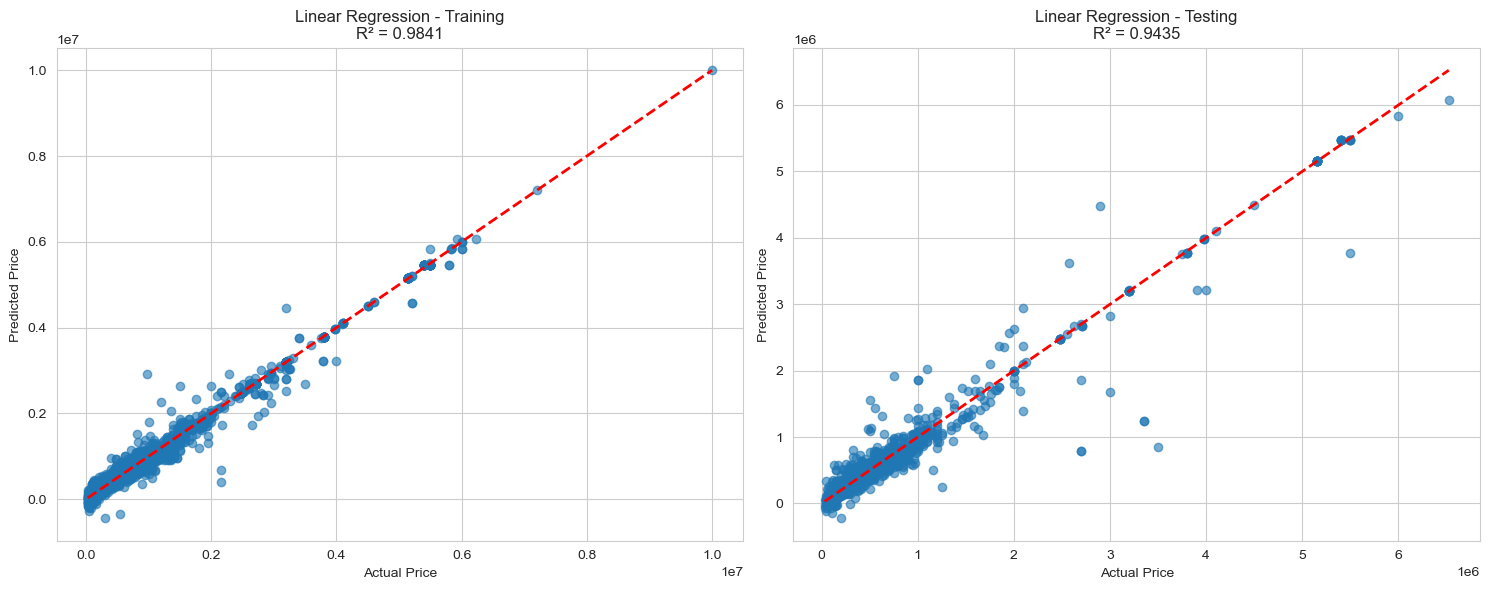

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

train_pred_lr = lin_reg.predict(x_train)
test_pred_lr = lin_reg.predict(x_test)

train_r2 = r2_score(y_train, train_pred_lr)
test_r2 = r2_score(y_test, test_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_train, train_pred_lr, alpha=0.6)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', linewidth=2)
axes[0].set_title(f"Linear Regression - Training\nR² = {train_r2:.4f}")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].grid(True)

axes[1].scatter(y_test, test_pred_lr, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2)
axes[1].set_title(f"Linear Regression - Testing\nR² = {test_r2:.4f}")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#Random Forest Regressoion
from sklearn.metrics import r2_score
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(x_train, y_train)

train_pred_rf = rf_reg.predict(x_train)
train_r2_rf = r2_score(y_train, train_pred_rf)
train_mae_rf = mean_absolute_error(y_train, train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, train_pred_rf))

print("----- TRAINING PERFORMANCE -----")
print("R2   :", train_r2_rf)
print("MAE  :", train_mae_rf)
print("RMSE :", train_rmse_rf)


----- TRAINING PERFORMANCE -----
R2   : 0.9907086087776965
MAE  : 30070.942609473404
RMSE : 77628.87675634162


In [ ]:
test_pred_rf = rf_reg.predict(x_test)
test_r2_rf = r2_score(y_test, test_pred_rf)
test_mae_rf = mean_absolute_error(y_test, test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, test_pred_rf))
print("\n----- TEST PERFORMANCE -----")
print("R2   :", test_r2_rf)
print("MAE  :", test_mae_rf)
print("RMSE :", test_rmse_rf)


----- TEST PERFORMANCE -----
R2   : 0.9612718504296034
MAE  : 76566.97744373791
RMSE : 159328.90336991532


In [ ]:
numeric_features_importance = pd.DataFrame({
    'numeric_features': x_train.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(numeric_features_importance.head(10))

                numeric_features  Importance
4                   transmission    0.259268
659            max_power_190 bhp    0.255539
2                           fuel    0.066783
0                           year    0.059727
1                      km_driven    0.053094
1036  torque_202Nm@ 3600-5200rpm    0.021279
159           mileage_16.78 kmpl    0.019130
481               engine_2487 CC    0.019044
321           mileage_22.37 kmpl    0.016695
671         max_power_214.56 bhp    0.012107


Text(0.5, 1.0, 'Random Forest - Testing\nR² = 0.9613')

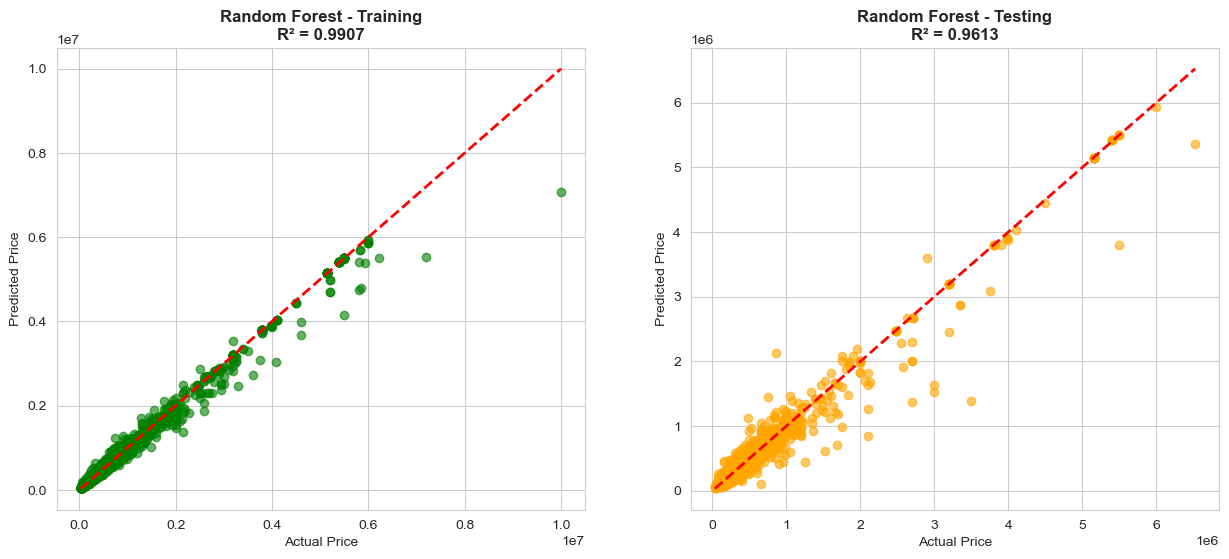

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(y_train, train_pred_rf, alpha=0.6, color='green')
axes[0].plot([y_train.min(), y_train.max()],[y_train.min(), y_train.max()], 'r--', linewidth=2)
axes[0].set_title(f"Random Forest - Training\nR² = {train_r2_rf:.4f}", fontweight='bold')
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].grid(True)
axes[0].set_title(f"Random Forest - Training\nR² = {train_r2_rf:.4f}", fontweight='bold')

axes[1].scatter(y_test, test_pred_rf, alpha=0.6, color='orange')
axes[1].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title(f"Random Forest - Testing\nR² = {test_r2_rf:.4f}", fontweight='bold')
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].grid(True)
axes[1].set_title(f"Random Forest - Testing\nR² = {test_r2_rf:.4f}", fontweight='bold')

In [ ]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

# Save the fitted scaler
joblib.dump(scaler, "scaler.pkl")

knn_reg = KNeighborsRegressor(n_neighbors=5)  

knn_reg.fit(x_train_scaled, y_train)

joblib.dump(knn_reg, "knn_regressor_model.pkl")

train_pred = knn_reg.predict(x_train_scaled)
test_pred = knn_reg.predict(x_test_scaled)

print("----- TRAINING PERFORMANCE -----")
print("R2   :", r2_score(y_train, train_pred))
print("MAE  :", mean_absolute_error(y_train, train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\n----- TEST PERFORMANCE -----")
print("R2   :", r2_score(y_test, test_pred))
print("MAE  :", mean_absolute_error(y_test, test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))

----- TRAINING PERFORMANCE -----
R2   : 0.9168421199287553
MAE  : 80096.86911719471
RMSE : 232238.7223190716

----- TEST PERFORMANCE -----
R2   : 0.910027721057015
MAE  : 99091.22287822879
RMSE : 242848.571984427


In [ ]:
dt_reg = DecisionTreeRegressor(random_state=42)

# Train the model
dt_reg.fit(x_train, y_train)

# Predictions
train_pred = dt_reg.predict(x_train)
test_pred = dt_reg.predict(x_test)

print("----- TRAINING PERFORMANCE -----")
print("R2   :", r2_score(y_train, train_pred))
print("MAE  :", mean_absolute_error(y_train, train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\n----- TEST PERFORMANCE -----")
print("R2   :", r2_score(y_test, test_pred))
print("MAE  :", mean_absolute_error(y_test, test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))

----- TRAINING PERFORMANCE -----
R2   : 0.9996452090741117
MAE  : 3573.300957890669
RMSE : 15169.42715306011

----- TEST PERFORMANCE -----
R2   : 0.9627275180224284
MAE  : 79854.15886476172
RMSE : 156305.89237633251


In [ ]:
print('LinearRegression :', train_r2, test_r2)
print('Random Forest :', train_r2_rf, test_r2_rf)


LinearRegression : 0.9840752166817428 0.9435033138553736
Random Forest : 0.9907086087776965 0.9612718504296034


In [ ]:
joblib.dump(rf_reg,"best_model.pkl")

['best_model.pkl']